# CSD361 - Lab Assignment 1
## Data Preprocessing and Linear Regression


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

DATA_PATH = r'C:\Users\Tanvi\Downloads\CSD361 LAB ASSIGNMENT 1\Taxi_Trips_-_2024_20240408.csv'  

df = pd.read_csv(DATA_PATH)
print(df.shape)


(865247, 23)


## Part I

In [17]:
df = pd.read_csv(DATA_PATH)

# 1. Number of observations and attributes
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of attributes (columns): {df.shape[1]}")
print()
print(df.dtypes)


Number of observations (rows): 865247
Number of attributes (columns): 23

Trip ID                           str
Taxi ID                           str
Trip Start Timestamp              str
Trip End Timestamp                str
Trip Seconds                  float64
Trip Miles                    float64
Pickup Census Tract           float64
Dropoff Census Tract          float64
Pickup Community Area         float64
Dropoff Community Area        float64
Fare                          float64
Tips                          float64
Tolls                         float64
Extras                        float64
Trip Total                    float64
Payment Type                      str
Company                           str
Pickup Centroid Latitude      float64
Pickup Centroid Longitude     float64
Pickup Centroid Location          str
Dropoff Centroid Latitude     float64
Dropoff Centroid Longitude    float64
Dropoff Centroid  Location        str
dtype: object


**Attribute type classification:**

| Type | Attributes |
|---|---|
| **Numerical** | Trip Seconds, Trip Miles, Fare, Tips, Tolls, Extras, Trip Total, Pickup/Dropoff Centroid Latitude & Longitude |
| **Categorical** | Payment Type, Company, Pickup Community Area, Dropoff Community Area |
| **Identifier** | Trip ID, Taxi ID, Pickup/Dropoff Census Tract, Pickup/Dropoff Centroid Location (WKT string) |
| **Timestamp** | Trip Start Timestamp, Trip End Timestamp |

*(Community Area is a location code, not a real number — treated as categorical.)*

In [18]:
# 3. Missing values in each attribute
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)



                            Missing Count  Missing %
Dropoff Census Tract               551393      63.73
Pickup Census Tract                537996      62.18
Dropoff Community Area              83853       9.69
Dropoff Centroid  Location          79675       9.21
Dropoff Centroid Latitude           79675       9.21
Dropoff Centroid Longitude          79675       9.21
Pickup Community Area               23195       2.68
Pickup Centroid Latitude            22966       2.65
Pickup Centroid Location            22966       2.65
Pickup Centroid Longitude           22966       2.65
Fare                                 2045       0.24
Extras                               2045       0.24
Tolls                                2045       0.24
Trip Total                           2045       0.24
Tips                                 2045       0.24
Trip Seconds                          169       0.02
Trip End Timestamp                      8       0.00
Trip Miles                              6     

In [19]:
# 4. Duplicate records
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate Trip IDs: {df.duplicated(subset=['Trip ID']).sum()}")


Fully duplicated rows: 0
Duplicate Trip IDs: 0


In [20]:
# 5. Descriptive statistics
stats_cols = ['Trip Seconds', 'Trip Miles', 'Fare', 'Tips', 'Tolls', 'Extras']
desc = df[stats_cols].describe().T
desc['skew'] = df[stats_cols].skew()
desc['missing'] = df[stats_cols].isnull().sum()
print(desc)


                 count         mean          std  min     25%     50%  \
Trip Seconds  865078.0  1150.532018  1584.243513  0.0  459.00  900.00   
Trip Miles    865241.0     6.563330     8.279528  0.0    0.91    3.07   
Fare          863202.0    22.057441    25.145823  0.0    8.00   15.75   
Tips          863202.0     2.761349     4.132953  0.0    0.00    0.00   
Tolls         863202.0     0.063232    12.955213  0.0    0.00    0.00   
Extras        863202.0     2.149285    19.319780  0.0    0.00    0.00   

                  75%       max        skew  missing  
Trip Seconds  1591.00  86340.00   24.576602      169  
Trip Miles      11.71   3093.47   75.074996        6  
Fare            33.75   9999.75  159.398824     2045  
Tips             4.00    200.00    3.063410     2045  
Tolls            0.00   4444.44  323.047462     2045  
Extras           3.00   5051.10  198.057306     2045  


In [2]:
# 6. Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(stats_cols):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    sns.histplot(data[data <= upper], bins=60, ax=axes[i], color='#4C72B0', kde=True)
    axes[i].set_title(f'Distribution of {col} (clipped at 99th pct)', fontsize=10)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

---
## Part II
### Feature engineering and selection

In [22]:
 work = df.copy()
work['Trip Start Timestamp'] = pd.to_datetime(work['Trip Start Timestamp'], errors='coerce')

core_cols = ['Fare', 'Trip Seconds', 'Trip Miles', 'Pickup Community Area',
             'Dropoff Community Area', 'Trip Start Timestamp']
work = work.dropna(subset=core_cols)

work = work[(work['Trip Seconds'] > 0) & (work['Trip Miles'] > 0) & (work['Fare'] > 0)]

work = work[(work['Trip Seconds'] <= 4*3600) & (work['Fare'] <= 300) & (work['Trip Miles'] <= 100)]

work['hour'] = work['Trip Start Timestamp'].dt.hour
work['day_of_week'] = work['Trip Start Timestamp'].dt.dayofweek   # 0 = Monday
work['month'] = work['Trip Start Timestamp'].dt.month
work['is_weekend'] = (work['day_of_week'] >= 5).astype(int)

FEATURES = ['Trip Seconds', 'Trip Miles', 'Pickup Community Area',
            'Dropoff Community Area', 'hour', 'day_of_week', 'month', 'is_weekend']
TARGET = 'Fare'

model_df = work[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(f"Rows after cleaning: {len(model_df)}")
print(f"Selected features: {FEATURES}")


C:\Users\Tanvi\AppData\Local\Temp\ipykernel_10128\3316444119.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  work['Trip Start Timestamp'] = pd.to_datetime(work['Trip Start Timestamp'], errors='coerce')


Rows after cleaning: 696310
Selected features: ['Trip Seconds', 'Trip Miles', 'Pickup Community Area', 'Dropoff Community Area', 'hour', 'day_of_week', 'month', 'is_weekend']


**Justification for feature choice:**

- **Trip Seconds & Trip Miles** — direct physical measures of trip effort/duration. Taxi fares are computed largely from time and distance, so these are the strongest predictors, and (as route/traffic estimates) they are reasonably available at prediction time.
- **Pickup/Dropoff Community Area** — proxy for zone-based pricing, congestion, and distance-to-downtown effects not fully captured by raw distance (e.g. airport trips, expressway routes).
- **hour, day_of_week, month, is_weekend** (derived from Trip Start Timestamp) — capture temporal demand/surge patterns, rush-hour traffic, and seasonal fare variation.
- **Excluded:** Tips / Tolls / Extras / Trip Total — these are not available before, or are directly derived from, the fare (Trip Total literally sums Fare + Tips + Tolls + Extras, so including it would leak the target). Company / Taxi ID / Trip ID are identifiers with no predictive value. Census tracts have >60% missing values.

In [23]:
SAMPLE_N = 60000
sample_df = model_df.sample(n=min(SAMPLE_N, len(model_df)), random_state=42).reset_index(drop=True)
print(f"Using a random sample of N={len(sample_df)} rows for modeling.")

X = sample_df[FEATURES].values
y = sample_df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Using a random sample of N=60000 rows for modeling.


## Part III

In [24]:
results = {}

# Model 1
lr1 = LinearRegression()
lr1.fit(X_train, y_train)
pred1 = lr1.predict(X_test)
mae1, mse1 = mean_absolute_error(y_test, pred1), mean_squared_error(y_test, pred1)
results['Original'] = (mae1, mse1)
print(f"Model 1 (Original):     MAE={mae1:.4f}  MSE={mse1:.4f}")

# Model 2
scaler_mm = MinMaxScaler()
X_train_mm, X_test_mm = scaler_mm.fit_transform(X_train), scaler_mm.transform(X_test)
lr2 = LinearRegression()
lr2.fit(X_train_mm, y_train)
pred2 = lr2.predict(X_test_mm)
mae2, mse2 = mean_absolute_error(y_test, pred2), mean_squared_error(y_test, pred2)
results['Min-Max'] = (mae2, mse2)
print(f"Model 2 (Min-Max):      MAE={mae2:.4f}  MSE={mse2:.4f}")

# Model 3
scaler_std = StandardScaler()
X_train_std, X_test_std = scaler_std.fit_transform(X_train), scaler_std.transform(X_test)
lr3 = LinearRegression()
lr3.fit(X_train_std, y_train)
pred3 = lr3.predict(X_test_std)
mae3, mse3 = mean_absolute_error(y_test, pred3), mean_squared_error(y_test, pred3)
results['Standardized'] = (mae3, mse3)
print(f"Model 3 (Standardized): MAE={mae3:.4f}  MSE={mse3:.4f}")

print()
res_df = pd.DataFrame(results, index=['MAE', 'MSE']).T
print(res_df.round(4))


Model 1 (Original):     MAE=2.6938  MSE=28.4119
Model 2 (Min-Max):      MAE=2.6938  MSE=28.4119
Model 3 (Standardized): MAE=2.6938  MSE=28.4119

                 MAE      MSE
Original      2.6938  28.4119
Min-Max       2.6938  28.4119
Standardized  2.6938  28.4119


**Results table:**

| Model | MAE | MSE |
|---|---|---|
| Original | 2.6938 | 28.4119 |
| Min-Max | 2.6938 | 28.4119 |
| Standardized | 2.6938 | 28.4119 |

**3.**
No — the values are identical (to floating-point precision). Ordinary Least Squares finds the exact global minimum of the convex MSE loss regardless of feature scale; scaling is a linear reparameterization of X, and the closed-form solver compensates fully through the coefficient values.

**4.**
Yes. Min-Max scaling and Standardization are both *linear, invertible* transformations of the input features, and linear regression's fitted hyperplane (hence its predictions) is invariant under any invertible linear transformation of the inputs — only the coefficients' scale/interpretation changes, not the predictions.

**5.**
All three are equally accurate, so from a pure-accuracy standpoint it does not matter. In practice, the **Standardized** model is recommended because: (a) its coefficients are directly comparable in magnitude, aiding feature-importance interpretation; (b) it generalizes far better to scale-sensitive downstream methods — gradient descent, regularization (Ridge/Lasso), or more complex models — exactly the effect explored in Part IV below.

## Part IV

In [3]:
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def gradient_descent(X, y, lr=0.001, n_iters=500):
    """Batch gradient descent for linear regression. Returns weights and MSE history."""
    Xb = add_bias(X)
    n, d = Xb.shape
    w = np.zeros((d, 1))
    mse_history = []
    for it in range(n_iters):
        pred = Xb @ w
        error = pred - y
        mse = np.mean(error**2)
        mse_history.append(mse)
        if not np.isfinite(mse) or mse > 1e12:
            mse_history.extend([np.inf] * (n_iters - len(mse_history)))
            break
        grad = (2/n) * (Xb.T @ error)
        w = w - lr * grad
    return w, np.array(mse_history)

y_train_col = y_train.reshape(-1, 1)
datasets = {'Original': X_train, 'Min-Max': X_train_mm, 'Standardized': X_train_std}


NameError: name 'y_train' is not defined

### IV.1-2 

Original       : DIVERGED at iteration 3 (lr=0.001)
Min-Max        : Final MSE = 143.5992
Standardized   : Final MSE = 26.9607


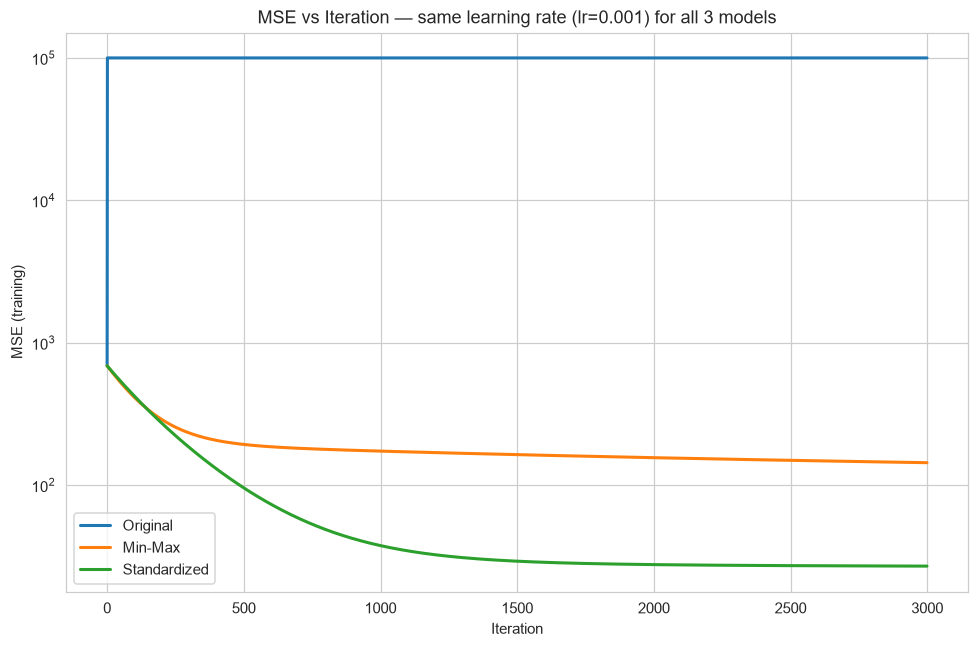

In [26]:
LR_COMMON = 0.001
N_ITERS = 3000
histories = {}
for name, Xd in datasets.items():
    w, hist = gradient_descent(Xd, y_train_col, lr=LR_COMMON, n_iters=N_ITERS)
    histories[name] = hist
    finite_hist = hist[np.isfinite(hist)]
    if len(finite_hist) < N_ITERS:
        print(f"{name:15s}: DIVERGED at iteration {len(finite_hist)} (lr={LR_COMMON})")
    else:
        print(f"{name:15s}: Final MSE = {hist[-1]:.4f}")

plt.figure(figsize=(9,6))
for name, hist in histories.items():
    plt.plot(np.clip(hist, 0, 1e5), label=name, linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('MSE (training)'); plt.yscale('log')
plt.title(f'MSE vs Iteration — same learning rate (lr={LR_COMMON}) for all 3 models')
plt.legend(); plt.tight_layout(); plt.show()


**a. Iterations required for convergence:** Standardized converges by far the fastest (well-conditioned, comparable-scale gradients). Min-Max is markedly slower — its bounded [0,1] range produces small, imbalanced gradients, so it has not fully converged even after 3000 iterations. Original (raw-scale) features **diverge** almost immediately at this learning rate, because the huge feature magnitudes (e.g. Trip Seconds up to ~14,000) blow up the gradient.

**b. Final MSE:** Standardized reaches ≈27, essentially matching the closed-form OLS result (28.41) from Part III. Min-Max is still at ≈144 (not yet converged). Original has diverged entirely (MSE → ∞).

**c. Sensitivity to learning rate:** Original features are extremely sensitive — a stable learning rate must be many orders of magnitude smaller. Standardized features are the least sensitive, tolerating a wide range of learning rates with a well-conditioned, isotropic loss surface.

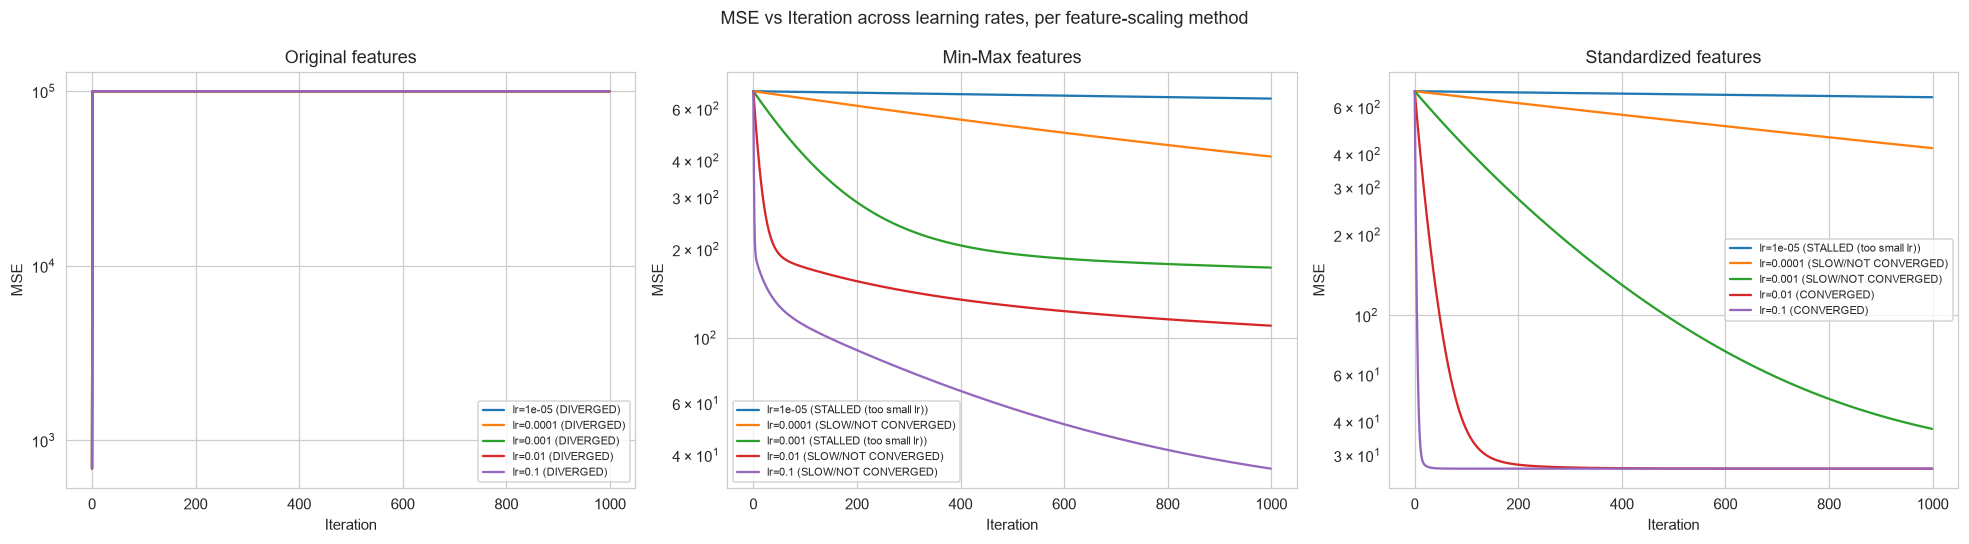

         Original                 Min-Max            Standardized
0.00001  DIVERGED  STALLED (too small lr)  STALLED (too small lr)
0.00010  DIVERGED      SLOW/NOT CONVERGED      SLOW/NOT CONVERGED
0.00100  DIVERGED  STALLED (too small lr)      SLOW/NOT CONVERGED
0.01000  DIVERGED      SLOW/NOT CONVERGED               CONVERGED
0.10000  DIVERGED      SLOW/NOT CONVERGED               CONVERGED

Final MSE per (scaling, learning rate):
         Original  Min-Max  Standardized
0.00001       inf  649.445       653.321
0.00010       inf  412.756       421.484
0.00100       inf  173.151        37.594
0.01000       inf  109.937        26.687
0.10000       inf   35.933        26.687


In [27]:
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1]
N_ITERS_SWEEP = 1000
sweep_results, sweep_final_mse = {name: {} for name in datasets}, {name: {} for name in datasets}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, Xd) in zip(axes, datasets.items()):
    hists = {lr: gradient_descent(Xd, y_train_col, lr=lr, n_iters=N_ITERS_SWEEP)[1] for lr in learning_rates}
    finite_finals = [h[-1] for h in hists.values() if np.isfinite(h[-1])]
    best_final = min(finite_finals) if finite_finals else np.inf
    for lr in learning_rates:
        hist = hists[lr]
        finite_hist = hist[np.isfinite(hist)]
        if len(finite_hist) < N_ITERS_SWEEP:
            status = 'DIVERGED'
        else:
            rel_change = abs(hist[-1] - hist[-min(50,len(hist))]) / (hist[-min(50,len(hist))] + 1e-9)
            near_optimum = hist[-1] <= 1.05 * best_final
            status = 'CONVERGED' if (near_optimum and rel_change < 0.01) else \
                     ('STALLED (too small lr)' if rel_change < 0.01 else 'SLOW/NOT CONVERGED')
        sweep_results[name][lr] = status
        sweep_final_mse[name][lr] = hist[-1]
        ax.plot(np.clip(hist, 0, 1e5), label=f'lr={lr} ({status})')
    ax.set_title(f'{name} features'); ax.set_xlabel('Iteration'); ax.set_ylabel('MSE')
    ax.set_yscale('log'); ax.legend(fontsize=7)
plt.suptitle('MSE vs Iteration across learning rates, per feature-scaling method')
plt.tight_layout(); plt.show()

print(pd.DataFrame(sweep_results))
print()
print("Final MSE per (scaling, learning rate):")
print(pd.DataFrame(sweep_final_mse).round(3))


**a. Convergence:** Standardized features are the only scaling that fully converges to a near-optimal MSE (≈27, matching the closed-form solution) within the 1000-iteration budget — and does so at both lr=0.01 and lr=0.1, showing a wide "safe" band of usable rates.

**b. Slow convergence / stalling:** Min-Max normalized features never fully converge within 1000 iterations at any tested rate (final MSE ranges from ~650 down to ~36 as lr increases, but is still descending at the cutoff), because bounded [0,1] features produce smaller gradients and need proportionally more iterations. Both scalings essentially stall at the smallest rate (1e-5).

**c. Divergence:** For Original (unscaled) features, *every* tested rate from 1e-5 to 0.1 causes the loss to blow up within a few iterations — gradients computed on large raw magnitudes (Trip Seconds ~ thousands) are themselves enormous, so even tiny steps overshoot. A stable rate here would need to be several orders of magnitude smaller still (roughly 1e-7 or below).

### IV.4

Gradient descent's step for each weight is proportional to that feature's magnitude (∂L/∂w_j involves a factor of x_j). When features have very different scales (e.g. Trip Seconds ~0–14,000 vs. is_weekend ∈ {0,1}), the MSE loss surface — a paraboloid in weight-space — becomes highly **elongated / ill-conditioned**: very steep along large-magnitude feature directions, very flat along small-magnitude ones. A single learning rate that is stable for the steep direction is far too small for the flat direction (slow convergence), while a rate large enough for the flat direction **overshoots and diverges** in the steep direction.

This is formally the **condition number** of the Hessian (∝ XᵀX): raw features give a high condition number (poorly conditioned, elongated bowl), while Min-Max and Standardization rescale all features to comparable ranges, making the loss surface much more circular/isotropic (low condition number). This lets gradient descent use a single, much larger, uniformly effective learning rate and converge in far fewer iterations — exactly what we observed above. Standardization (zero mean, unit variance) is generally the best-conditioned of the two scaling schemes here.

## Part V 

Trip Seconds   : bounds=[-1174.50, 3285.50], outliers=1343 (2.24%)
Trip Miles     : bounds=[-14.97, 28.15], outliers=193 (0.32%)
Fare           : bounds=[-29.25, 70.75], outliers=238 (0.40%)

Total rows flagged as outliers (IQR method, any column): 1532 (2.55%)


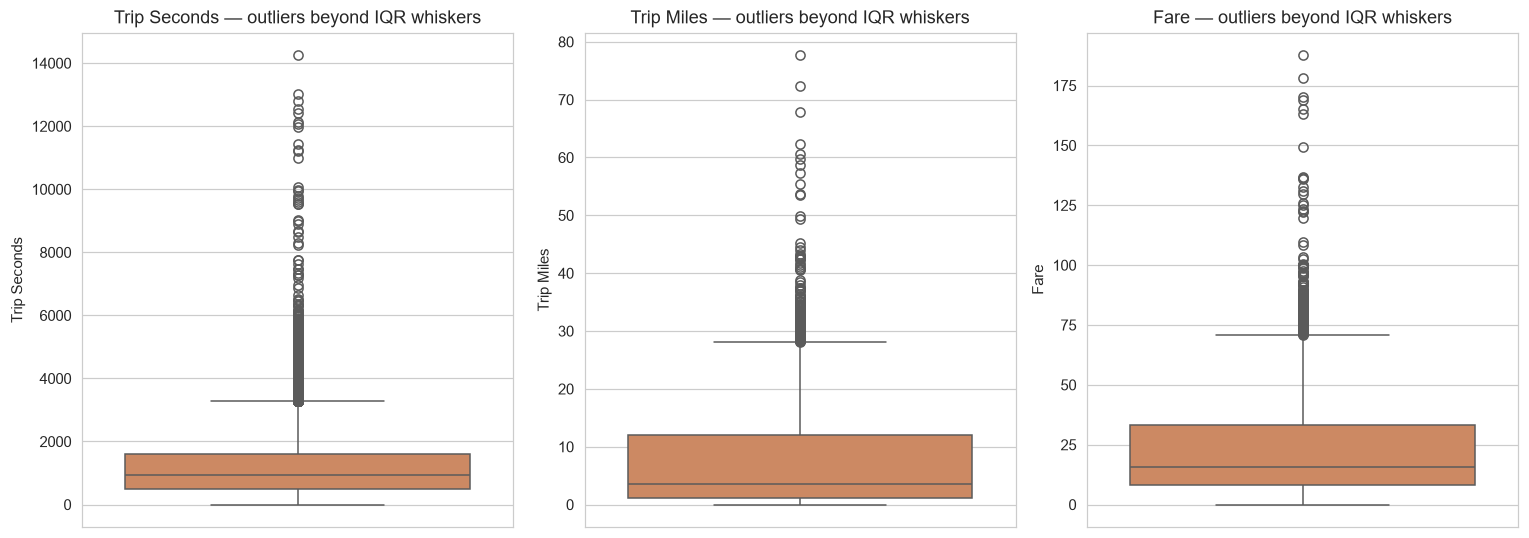

In [28]:
#V.1
outlier_cols = ['Trip Seconds', 'Trip Miles', 'Fare']
outlier_mask = pd.Series(False, index=sample_df.index)
for col in outlier_cols:
    Q1, Q3 = sample_df[col].quantile(0.25), sample_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    col_outliers = (sample_df[col] < lower) | (sample_df[col] > upper)
    print(f"{col:15s}: bounds=[{lower:.2f}, {upper:.2f}], outliers={col_outliers.sum()} "
          f"({col_outliers.sum()/len(sample_df)*100:.2f}%)")
    outlier_mask |= col_outliers
print(f"\nTotal rows flagged as outliers (IQR method, any column): {outlier_mask.sum()} "
      f"({outlier_mask.sum()/len(sample_df)*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=sample_df[col], ax=ax, color='#DD8452')
    ax.set_title(f'{col} — outliers beyond IQR whiskers')
plt.tight_layout(); plt.show()


In [29]:
#V.3
dataset_A = sample_df.copy()                     # Dataset A: original
dataset_B = sample_df[~outlier_mask].copy()       # Dataset B: outliers removed
print(f"Dataset A (original):         {len(dataset_A)} rows")
print(f"Dataset B (outliers removed): {len(dataset_B)} rows ({len(dataset_B)/len(dataset_A)*100:.1f}% retained)")

def train_eval(data):
    X, y = data[FEATURES].values, data[TARGET].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    pred = model.predict(X_test)
    return model, mean_absolute_error(y_test, pred), mean_squared_error(y_test, pred), model.score(X_test, y_test)

model_A, mae_A, mse_A, r2_A = train_eval(dataset_A)
model_B, mae_B, mse_B, r2_B = train_eval(dataset_B)
print(f"\nDataset A (with outliers):    MAE={mae_A:.4f}  MSE={mse_A:.4f}  R2={r2_A:.4f}")
print(f"Dataset B (outliers removed): MAE={mae_B:.4f}  MSE={mse_B:.4f}  R2={r2_B:.4f}")


Dataset A (original):         60000 rows
Dataset B (outliers removed): 58468 rows (97.4% retained)

Dataset A (with outliers):    MAE=2.6938  MSE=28.4119  R2=0.8810
Dataset B (outliers removed): MAE=2.5687  MSE=23.3379  R2=0.8875


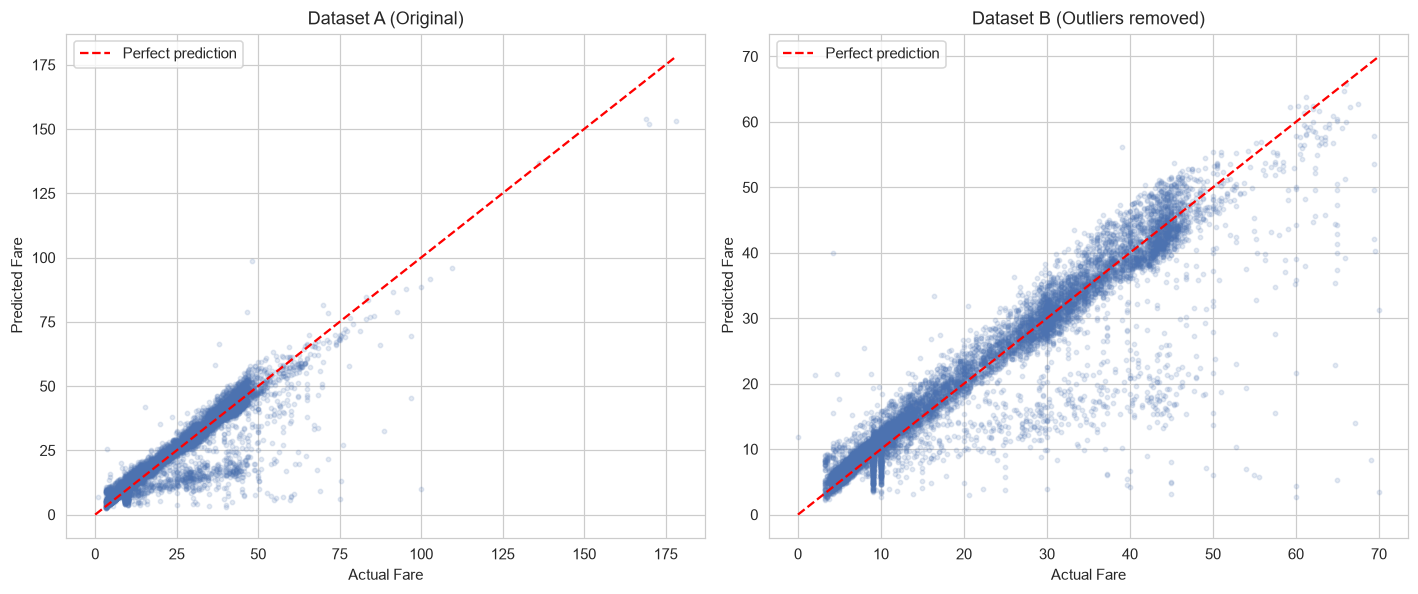

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, data, model) in zip(axes,
        [('Dataset A (Original)', dataset_A, model_A), ('Dataset B (Outliers removed)', dataset_B, model_B)]):
    X, y = data[FEATURES].values, data[TARGET].values
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.15, s=8, color='#4C72B0')
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Fare'); ax.set_ylabel('Predicted Fare'); ax.set_title(name); ax.legend()
plt.tight_layout(); plt.show()


**V.3**

Not necessarily — it depends on the goal and metric:

- **MAE** improved from 2.69 → 2.57, and **MSE** improved more sharply, from 28.41 → 23.34, and R² rose from 0.881 → 0.888. MSE improves more dramatically because it squares errors — a few extreme outliers contribute disproportionately large squared errors, so removing them mechanically shrinks MSE.
- These gains partly reflect a **less variable, easier target distribution** after removal, not purely a "better" model — R² is computed against a lower-variance target once outliers are gone.
- **Practical risk:** if the outliers are legitimate rare events (e.g. genuine long airport/inter-city trips), removing them means the model will systematically underpredict fares for exactly those real future trips — trading robustness/coverage for average-case accuracy on typical trips.
- **Conclusion:** outlier removal improved the reported error metrics on this dataset, but whether it "improves the model" depends on whether the deployment use-case cares about rare, high-value trips. A robust regression approach (e.g. Huber loss) or capping/winsorizing rather than deleting may be a better compromise than outright removal.